# 9. Ultimate Harmonic EDA

This notebook turns the earlier artifacts into a narrative EDA around one guiding question:

**Did popular music harmony become simpler, or did it become differently complex?**

The working hypothesis from notebooks 5-8 is that the answer is not one-dimensional. Older popular harmony appears more cadence- and dominant-resolution-heavy; newer popular harmony appears more loop-centered, genre-specific, and concentrated around reusable harmonic objects. This notebook tests that story from several angles.

The notebook answers these practical questions:

1. Which harmonic `n`-grams became more or less popular?
2. Did harmonic diversity increase or decrease through time?
3. Did repetition and loop concentration increase?
4. Did functional/dominant harmony decline?
5. Which genres have the broadest or narrowest harmonic vocabulary?
6. Which artists are harmonic generalists or specialists?
7. Which harmonic classes are global stop-grams versus signature vocabulary?
8. When does the historical vocabulary appear to change regime?

The intended reading is cumulative: frequency shifts identify the musical objects, diversity/concentration tests whether the vocabulary broadens or narrows, genre and artist sections localize the effect, and the final takeaways convert the EDA into claims worth writing up.

Inputs: notebooks 5-8 should already have been run. Artist-level profiling is computed on demand from the raw chord file because the current DuckDB store does not yet persist a song-by-artist harmonic document table.

## Setup

In [1]:
from collections import Counter
from pathlib import Path
import importlib
import math
import os
import sys

CWD = Path.cwd()
ROOT = CWD.parent if (CWD / "utils").exists() else CWD
MPLCONFIGDIR = ROOT / ".matplotlib-cache"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import duckdb
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_DIR = ROOT / "notebooks"
sys.path = [p for p in sys.path if p != str(NOTEBOOK_DIR)]
sys.path.insert(0, str(NOTEBOOK_DIR))
for module_name in list(sys.modules):
    if module_name == "utils" or module_name.startswith("utils."):
        del sys.modules[module_name]

from utils import duckdb_store as ds
from utils import ngram_features as nf

ds = importlib.reload(ds)
nf = importlib.reload(nf)
expected = {
    "duckdb_store": (NOTEBOOK_DIR / "utils" / "duckdb_store.py").resolve(),
    "ngram_features": (NOTEBOOK_DIR / "utils" / "ngram_features.py").resolve(),
}
loaded = {
    "duckdb_store": Path(ds.__file__).resolve(),
    "ngram_features": Path(nf.__file__).resolve(),
}
assert loaded == expected, f"Imported wrong utility module(s): {loaded}; expected {expected}"

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

RAW_PATH = ROOT / "data" / "raw" / "chordonomicon_v2.csv"
DB_PATH = ROOT / "data" / "processed" / "harmonic_trends.duckdb"
ANALYSIS_DIR = ROOT / "data" / "processed" / "analysis"
INTERPRETATION_DIR = ROOT / "data" / "processed" / "interpretation"
CORPUS_DIR = ROOT / "data" / "processed" / "corpus_linguistics"
OUT_DIR = ROOT / "data" / "processed" / "ultimate_eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)

NS = tuple(range(3, 9))
MIN_DECADE = 1950
MIN_TERM_COUNT = 100
TOP_K = 20

# Artist profiling can take several minutes because it streams raw chord strings.
RUN_ARTIST_PROFILE = True
MIN_ARTIST_SONGS = 100
MAX_ARTISTS = 250
ARTIST_NS = (3, 4, 5)
CHUNKSIZE = 25_000

for path in [RAW_PATH, DB_PATH, ANALYSIS_DIR, INTERPRETATION_DIR, CORPUS_DIR]:
    assert path.exists(), path

{
    "python": sys.executable,
    "duckdb_version": duckdb.__version__,
    "root": str(ROOT),
    "out_dir": str(OUT_DIR),
    **{name: str(path) for name, path in loaded.items()},
}

{'python': '/usr/local/bin/python3',
 'duckdb_version': '1.5.2',
 'root': '/Users/juansalinas/Documents/GitHub/harmonic-trends',
 'out_dir': '/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/ultimate_eda',
 'duckdb_store': '/Users/juansalinas/Documents/GitHub/harmonic-trends/notebooks/utils/duckdb_store.py',
 'ngram_features': '/Users/juansalinas/Documents/GitHub/harmonic-trends/notebooks/utils/ngram_features.py'}

## Helpers

In [2]:
def entropy_from_counts(values) -> float:
    vals = [float(v) for v in values if pd.notna(v) and v > 0]
    total = sum(vals)
    if total <= 0:
        return 0.0
    return -sum((v / total) * math.log(v / total) for v in vals)


def gini(values) -> float:
    vals = sorted(float(v) for v in values if pd.notna(v) and v >= 0)
    n = len(vals)
    if n == 0:
        return float("nan")
    total = sum(vals)
    if total == 0:
        return 0.0
    weighted = sum((i + 1) * v for i, v in enumerate(vals))
    return (2 * weighted) / (n * total) - (n + 1) / n


def top_share(values, k: int) -> float:
    vals = sorted((float(v) for v in values if pd.notna(v) and v > 0), reverse=True)
    total = sum(vals)
    if total <= 0:
        return 0.0
    return sum(vals[:k]) / total


def diversity_summary(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    rows = []
    for key, sub in df.groupby(group_cols, dropna=False):
        if not isinstance(key, tuple):
            key = (key,)
        counts = sub["count"].astype(float).tolist()
        entropy = entropy_from_counts(counts)
        vocab_size = int(sub["harmonic_id"].nunique())
        total_count = int(sub["count"].sum())
        rows.append(
            {
                **dict(zip(group_cols, key)),
                "vocabulary_size": vocab_size,
                "total_count": total_count,
                "total_windows": int(sub["total_windows"].max()) if "total_windows" in sub else total_count,
                "song_count": int(sub["song_count"].max()) if "song_count" in sub else None,
                "entropy": entropy,
                "normalized_entropy": entropy / math.log(vocab_size) if vocab_size > 1 else 0.0,
                "effective_vocabulary": math.exp(entropy),
                "top1_share": top_share(counts, 1),
                "top5_share": top_share(counts, 5),
                "top20_share": top_share(counts, 20),
                "gini": gini(counts),
            }
        )
    return pd.DataFrame(rows)


def slope_by_group(df: pd.DataFrame, x_col: str, y_col: str, group_cols: list[str]) -> pd.DataFrame:
    rows = []
    for key, sub in df.dropna(subset=[x_col, y_col]).groupby(group_cols, dropna=False):
        if not isinstance(key, tuple):
            key = (key,)
        xs = sub[x_col].astype(float).to_list()
        ys = sub[y_col].astype(float).to_list()
        if len(xs) < 2:
            slope = float("nan")
        else:
            xbar = sum(xs) / len(xs)
            ybar = sum(ys) / len(ys)
            denom = sum((x - xbar) ** 2 for x in xs)
            slope = sum((x - xbar) * (y - ybar) for x, y in zip(xs, ys)) / denom if denom else float("nan")
        rows.append({**dict(zip(group_cols, key)), f"{y_col}_slope": slope})
    return pd.DataFrame(rows)


def short_label(example: str, harmonic_id: str) -> str:
    return f"{example} ({str(harmonic_id).split('_', 1)[-1][:6]})"


def save_table(df: pd.DataFrame, filename: str) -> Path:
    path = OUT_DIR / filename
    df.to_csv(path, index=False)
    return path

## Load Distilled Tables

In [3]:
con = duckdb.connect(str(DB_PATH), read_only=True)
ds.configure_connection(con)

try:
    available_tables = set(con.execute("SHOW TABLES").fetchdf()["name"])
    required = {"song_metadata", "song_ngram_summary", "harmonic_document_terms", "harmonic_ngrams"}
    missing = sorted(required - available_tables)
    assert not missing, f"Missing required DuckDB tables: {missing}"

    document_terms = con.execute(
        """
        SELECT *
        FROM harmonic_document_terms
        WHERE n BETWEEN 3 AND 8
          AND count >= ?
        """,
        [MIN_TERM_COUNT],
    ).fetchdf()

    song_length_by_decade = con.execute(
        """
        SELECT
            m.decade,
            COUNT(*) AS songs,
            AVG(s.n_chords) AS mean_chords,
            MEDIAN(s.n_chords) AS median_chords,
            QUANTILE_CONT(s.n_chords, 0.90) AS p90_chords
        FROM song_metadata m
        JOIN song_ngram_summary s USING (id)
        WHERE m.decade >= ?
        GROUP BY m.decade
        ORDER BY m.decade
        """,
        [MIN_DECADE],
    ).fetchdf()
finally:
    con.close()

decade_terms = document_terms[document_terms["document_type"] == "decade_1950_plus"].copy()
decade_terms["decade"] = decade_terms["document_value"].astype(int)
genre_terms = document_terms[document_terms["document_type"] == "main_genre"].copy()
genre_terms = genre_terms.rename(columns={"document_value": "main_genre"})

largest_rises = pd.read_csv(INTERPRETATION_DIR / "largest_supported_decade_rises.csv")
largest_declines = pd.read_csv(INTERPRETATION_DIR / "largest_supported_decade_declines.csv")
family_findings = pd.read_csv(INTERPRETATION_DIR / "family_findings.csv")
genre_families = pd.read_csv(INTERPRETATION_DIR / "genre_trend_families.csv")
stopgrams = pd.read_csv(CORPUS_DIR / "harmonic_stopgram_candidates.csv")
enrichment_top = pd.read_csv(CORPUS_DIR / "harmonic_enrichment_top.csv")
stratification_audit = pd.read_csv(CORPUS_DIR / "stratification_audit.csv")

{
    "document_terms": document_terms.shape,
    "decade_terms": decade_terms.shape,
    "genre_terms": genre_terms.shape,
    "rises": largest_rises.shape,
    "declines": largest_declines.shape,
}

{'document_terms': (191955, 12),
 'decade_terms': (86957, 13),
 'genre_terms': (104998, 12),
 'rises': (15, 12),
 'declines': (40, 12)}

## Reading Guide

The notebook intentionally separates **objects**, **documents**, and **claims**.

- Objects are harmonic classes such as `G C G` or `G Amin F`.
- Documents are decades, genres, and bounded artist catalogs.
- Claims compare object frequencies and document-level diversity/concentration.

This keeps the central question honest: if modern harmony looks simpler by one statistic but more specialized by another, the result should be described as a change in harmonic organization, not as a generic loss or gain of complexity.

## 1. Which Harmonic N-Grams Became More Popular?

Use the supported trend findings from notebook 6 for the cleanest first pass. These are endpoint comparisons after support filters, so they are better suited to interpretation than raw sparse yearly ranks.

In [4]:
display(largest_rises.sort_values(["n", "frequency_delta"], ascending=[True, False]).groupby("n").head(5))
display(largest_declines.sort_values(["n", "frequency_delta"], ascending=[True, True]).groupby("n").head(5))

save_table(largest_rises, "largest_supported_decade_rises.csv")
save_table(largest_declines, "largest_supported_decade_declines.csv")

,n,harmonic_id,representative_example_ngram,first_decade,last_decade,first_frequency,last_frequency,frequency_delta,frequency_ratio,first_count,last_count,change_rank
0,3,H3_950fb5de7bd72a8d,G Amin F,1960,2020,0.001993,0.020629,0.018636,10.351589,1168,86074,6
1,3,H3_0859351c7b2e5686,D C G,1950,2020,0.009560,0.021958,0.012398,2.296897,917,91617,12
2,3,H3_4e99eecf61b0edec,C G D,1950,2020,0.026709,0.038340,0.011631,1.435461,2562,159969,15
3,3,H3_908053190bacc7d7,F G Amin,1960,2020,0.002728,0.013788,0.011059,5.053691,1599,57528,16
4,3,H3_2bd39a67fe3535a8,G D C,1950,2020,0.008976,0.018004,0.009028,2.005852,861,75122,20
5,4,H4_e498ff144f418da0,G Amin F G,1960,2020,0.000909,0.005628,0.004720,6.193386,524,23182,16
6,4,H4_6f7528dbba7be76e,C G D C,1950,2020,0.006360,0.010872,0.004512,1.709374,599,44782,18
7,5,H5_fe03e54f5e258a8a,Amin G F Amin G,1970,2020,0.000727,0.003763,0.003035,5.173239,855,15297,22
8,5,H5_3f271b6cbfd476a8,C G D C G,1950,2020,0.005767,0.008768,0.003001,1.520478,533,35645,24
9,6,H6_6a56c71e698afea8,F C G Amin F C,1970,2020,0.000664,0.010473,0.009809,15.769525,770,42016,2


,n,harmonic_id,representative_example_ngram,first_decade,last_decade,first_frequency,last_frequency,frequency_delta,frequency_ratio,first_count,last_count,change_rank
0,3,H3_ede3c4f53675bbb0,G C G,1950,2020,0.077958,0.036051,-0.041908,0.462433,7478,150418,1
1,3,H3_35d6bfda85b78e3b,C G C,1950,2020,0.065438,0.031584,-0.033854,0.482654,6277,131781,2
2,3,H3_3569c7a41696606d,C G7 C,1950,2020,0.028481,0.001606,-0.026875,0.056389,2732,6701,3
3,3,H3_c7a280c94f7b2c52,D7 G C,1950,2020,0.019464,0.001486,-0.017978,0.076345,1867,6200,7
4,3,H3_614d8a0823c338e1,D G C,1950,2020,0.034955,0.019988,-0.014967,0.571810,3353,83397,9
9,4,H4_f6775591139fd92b,G C G C,1950,2020,0.036422,0.016423,-0.019999,0.450903,3430,67642,1
10,4,H4_ea9c499da62b44ab,C G C G,1950,2020,0.033310,0.017191,-0.016120,0.516072,3137,70805,2
11,4,H4_1b2efecb40653ba1,D G C G,1950,2020,0.021163,0.006898,-0.014265,0.325942,1993,28411,3
12,4,H4_12ecd8ebdeaeb0cb,G D G C,1950,2020,0.017531,0.004973,-0.012558,0.283680,1651,20484,7
13,4,H4_973515a9446c761a,G C G D,1950,2020,0.019092,0.006666,-0.012426,0.349160,1798,27457,8


PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/ultimate_eda/largest_supported_decade_declines.csv')

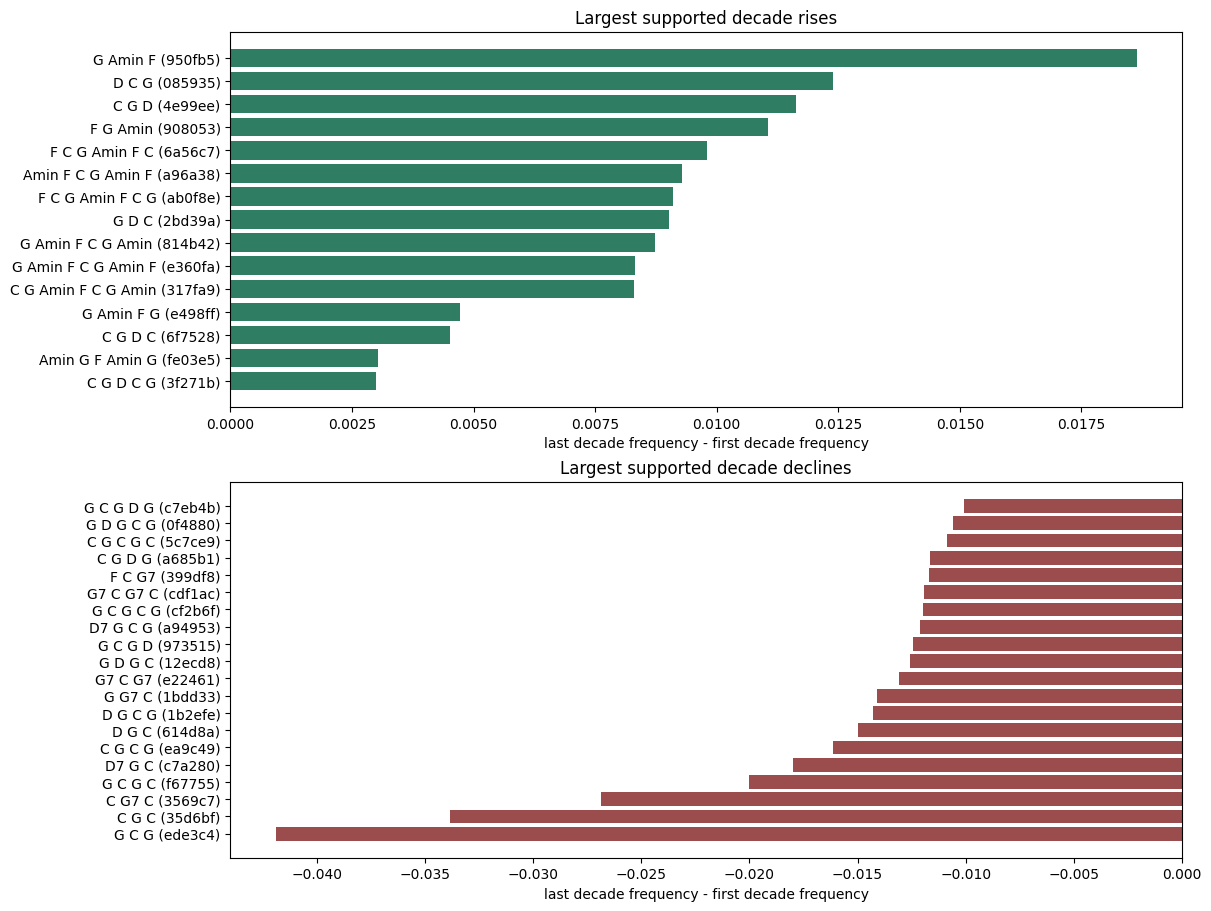

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), constrained_layout=True)

rise_plot = largest_rises.sort_values("frequency_delta", ascending=False).head(TOP_K).copy()
rise_plot["label"] = [short_label(e, h) for e, h in zip(rise_plot["representative_example_ngram"], rise_plot["harmonic_id"])]
axes[0].barh(rise_plot["label"][::-1], rise_plot["frequency_delta"][::-1], color="#2f7d62")
axes[0].set_title("Largest supported decade rises")
axes[0].set_xlabel("last decade frequency - first decade frequency")

decline_plot = largest_declines.sort_values("frequency_delta", ascending=True).head(TOP_K).copy()
decline_plot["label"] = [short_label(e, h) for e, h in zip(decline_plot["representative_example_ngram"], decline_plot["harmonic_id"])]
axes[1].barh(decline_plot["label"], decline_plot["frequency_delta"], color="#9b4d4d")
axes[1].set_title("Largest supported decade declines")
axes[1].set_xlabel("last decade frequency - first decade frequency")

plt.show()

## 2. Did Harmonic Diversity Increase Or Decrease?

Diversity is measured several ways because each answers a different version of complexity:

- `vocabulary_size`: how many supported harmonic classes appear.
- `normalized_entropy`: how evenly mass is spread across classes.
- `effective_vocabulary`: the entropy-equivalent number of equally common classes.
- `top5_share`: how much of the document is explained by its five largest classes.

If vocabulary size rises while entropy falls, the corpus is not simply simpler or more complex. It is broader but more concentrated.

In [6]:
decade_diversity = diversity_summary(decade_terms, ["decade", "n"]).sort_values(["n", "decade"])
decade_diversity_slopes = slope_by_group(decade_diversity, "decade", "normalized_entropy", ["n"]).merge(
    slope_by_group(decade_diversity, "decade", "top5_share", ["n"]),
    on="n",
)

display(decade_diversity)
display(decade_diversity_slopes)

save_table(decade_diversity, "decade_harmonic_diversity.csv")
save_table(decade_diversity_slopes, "decade_harmonic_diversity_slopes.csv")

,decade,n,vocabulary_size,total_count,total_windows,song_count,entropy,normalized_entropy,effective_vocabulary,top1_share,top5_share,top20_share,gini
0,1950,3,121,61167,95923,1748,3.976640,0.829194,53.337521,0.122255,0.366243,0.636814,0.607578
6,1960,3,534,486192,586092,9488,4.990889,0.794677,147.067075,0.084701,0.266860,0.477079,0.708847
12,1970,3,913,1002930,1207669,16110,5.325353,0.781217,205.480874,0.072859,0.239541,0.433008,0.744783
18,1980,3,1014,1315903,1532130,19411,5.325318,0.769370,205.473640,0.060725,0.212815,0.438963,0.777170
24,1990,3,1582,2711250,3026960,42474,5.453316,0.740291,233.531321,0.058970,0.213644,0.429622,0.819568
30,2000,3,2106,5896952,6387062,93549,5.497101,0.718336,243.983549,0.049929,0.188111,0.420704,0.853280
36,2010,3,2238,13280096,14216707,185492,5.398956,0.699951,221.175361,0.041438,0.172976,0.427376,0.869827
42,2020,3,1798,3829987,4172419,53594,5.449356,0.727121,232.608392,0.041768,0.170162,0.423675,0.839374
1,1950,4,101,40765,94175,1748,4.037205,0.874778,56.667742,0.084141,0.295867,0.624899,0.542379
7,1960,4,700,362500,576612,9488,5.498981,0.839401,244.442599,0.058723,0.181090,0.377462,0.640217


,n,normalized_entropy_slope,top5_share_slope
0,3,-0.001674,-0.002376
1,4,-0.000929,-0.002433
2,5,-0.000873,-0.002448
3,6,-0.000962,-0.002162
4,7,-0.001012,-0.002311
5,8,-0.001167,-0.002288


PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/ultimate_eda/decade_harmonic_diversity_slopes.csv')

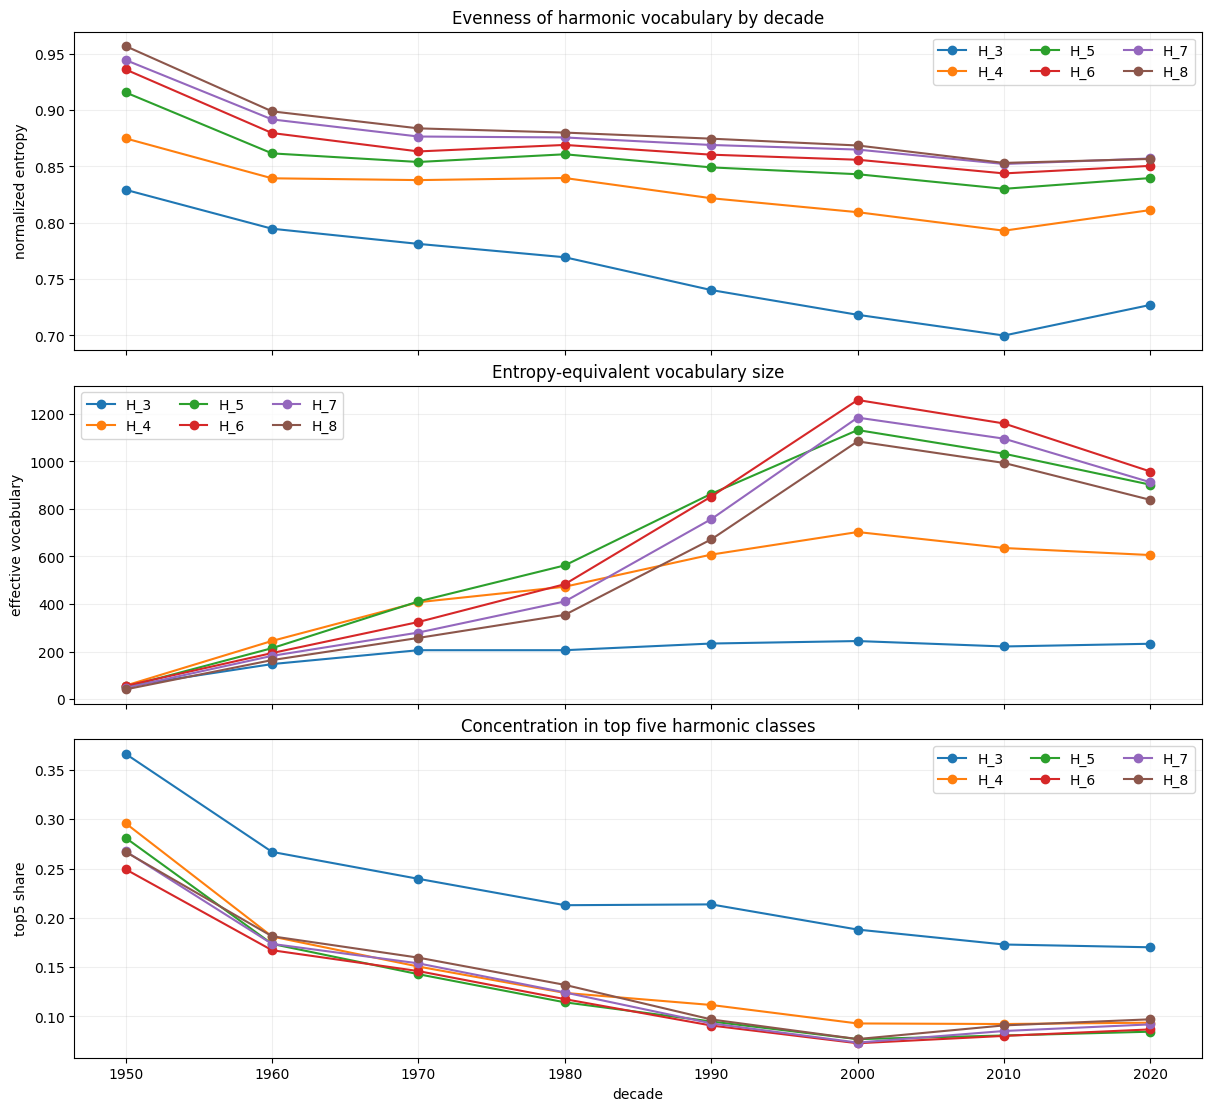

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True, constrained_layout=True)
for n, sub in decade_diversity.groupby("n"):
    axes[0].plot(sub["decade"], sub["normalized_entropy"], marker="o", label=f"H_{n}")
    axes[1].plot(sub["decade"], sub["effective_vocabulary"], marker="o", label=f"H_{n}")
    axes[2].plot(sub["decade"], sub["top5_share"], marker="o", label=f"H_{n}")

axes[0].set_title("Evenness of harmonic vocabulary by decade")
axes[0].set_ylabel("normalized entropy")
axes[1].set_title("Entropy-equivalent vocabulary size")
axes[1].set_ylabel("effective vocabulary")
axes[2].set_title("Concentration in top five harmonic classes")
axes[2].set_ylabel("top5 share")
axes[2].set_xlabel("decade")
for ax in axes:
    ax.grid(alpha=0.2)
    ax.legend(ncol=3)
plt.show()

### Complexity Reading

Read the diversity plots together, not independently. A rising vocabulary size with a rising `top5_share` means the corpus has more available harmonic types but also stronger concentration around dominant patterns. A falling normalized entropy means usage became less even; it does not by itself prove the underlying harmonic language became less sophisticated.

## 3. Did Song-Level Surface Length Change?

The current database has song-level window counts, so we can track chord-string length by decade. This is not harmonic sophistication by itself, but it is a useful companion to vocabulary concentration.

,decade,songs,mean_chords,median_chords,p90_chords
0,1950,1748,56.875858,50.0,97.0
1,1960,9488,63.771395,57.0,109.0
2,1970,16110,76.963253,69.0,132.0
3,1980,19411,80.930812,74.0,140.0
4,1990,42474,73.265833,67.0,128.0
5,2000,93549,70.274893,65.0,120.0
6,2010,185492,78.643047,75.0,124.0
7,2020,53594,79.852129,76.0,124.0


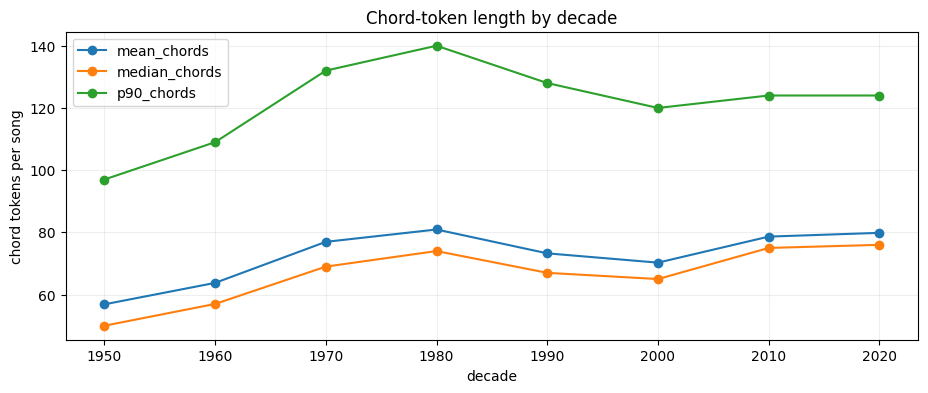

In [8]:
display(song_length_by_decade)
save_table(song_length_by_decade, "song_length_by_decade.csv")

ax = song_length_by_decade.plot(
    x="decade",
    y=["mean_chords", "median_chords", "p90_chords"],
    marker="o",
    figsize=(11, 4),
)
ax.set_title("Chord-token length by decade")
ax.set_ylabel("chord tokens per song")
ax.grid(alpha=0.2)
plt.show()

## 4. Did Functional/Dominant Harmony Decline?

Notebook 6 already surfaces the strongest examples. This section groups the interpreted family findings into decline, rise, and genre-specific buckets for a report-ready view.

In [9]:
family_summary = family_findings.copy()
family_summary["direction"] = family_summary["category"].str.replace("_family", "", regex=False)
display(family_summary[["category", "family_label", "family_kind", "n_values", "summary", "support"]])
save_table(family_summary, "interpreted_family_summary.csv")

counts = family_summary["category"].value_counts().rename_axis("category").reset_index(name="n_findings")
display(counts)

,category,family_label,family_kind,n_values,summary,support
0,decade_decline_family,G C loop,loop,"3,4,5,6,7,8",7.80% in 1950 -> 3.61% in 2020,"endpoint counts 7,478 -> 150,418; 6 related rows"
1,decade_decline_family,C G loop,loop,"3,4,5,6,7,8",6.54% in 1950 -> 3.16% in 2020,"endpoint counts 6,277 -> 131,781; 6 related rows"
2,decade_decline_family,C G7 loop,loop,3,2.85% in 1950 -> 0.16% in 2020,"endpoint counts 2,732 -> 6,701; 1 related rows"
3,decade_decline_family,D7 G C,phrase,"3,4",1.95% in 1950 -> 0.15% in 2020,"endpoint counts 1,867 -> 6,200; 2 related rows"
4,decade_decline_family,D G C,phrase,"3,4,5,6,7",3.50% in 1950 -> 2.00% in 2020,"endpoint counts 3,353 -> 83,397; 6 related rows"
5,decade_decline_family,G G7 C,phrase,3,1.59% in 1950 -> 0.18% in 2020,"endpoint counts 1,527 -> 7,632; 1 related rows"
6,decade_decline_family,G7 C loop,loop,"3,4",1.39% in 1950 -> 0.08% in 2020,"endpoint counts 1,333 -> 3,448; 2 related rows"
7,decade_decline_family,G D G,phrase,"4,5,6,7",1.75% in 1950 -> 0.50% in 2020,"endpoint counts 1,651 -> 20,484; 4 related rows"
8,decade_decline_family,G C G,phrase,"4,5,6,7",1.91% in 1950 -> 0.67% in 2020,"endpoint counts 1,798 -> 27,457; 4 related rows"
9,decade_decline_family,F C G7,phrase,3,1.25% in 1950 -> 0.08% in 2020,"endpoint counts 1,196 -> 3,309; 1 related rows"


,category,n_findings
0,genre_specific_family,15
1,decade_decline_family,10
2,decade_rise_family,9


## 5. Which Genres Have The Broadest Or Narrowest Harmonic Vocabulary?

In [10]:
genre_diversity = diversity_summary(genre_terms, ["main_genre", "n"]).sort_values(["n", "normalized_entropy"], ascending=[True, False])

genre_diversity_ranked = genre_diversity.copy()
genre_diversity_ranked["entropy_rank_within_n"] = genre_diversity_ranked.groupby("n")["normalized_entropy"].rank(ascending=False, method="first")
genre_diversity_ranked["concentration_rank_within_n"] = genre_diversity_ranked.groupby("n")["top5_share"].rank(ascending=False, method="first")

display(genre_diversity_ranked)
display(genre_diversity_ranked.sort_values(["n", "normalized_entropy"], ascending=[True, False]).groupby("n").head(5))
display(genre_diversity_ranked.sort_values(["n", "normalized_entropy"], ascending=[True, True]).groupby("n").head(5))

save_table(genre_diversity_ranked, "genre_harmonic_diversity.csv")

,main_genre,n,vocabulary_size,total_count,total_windows,song_count,entropy,normalized_entropy,effective_vocabulary,top1_share,top5_share,top20_share,gini,entropy_rank_within_n,concentration_rank_within_n
66,soul,3,624,384547,553616,7350,5.574782,0.866167,263.692146,0.035860,0.124588,0.310916,0.634577,1.0,12.0
12,electronic,3,177,176445,216106,2814,4.449054,0.859530,85.545982,0.054340,0.210564,0.502655,0.629307,2.0,2.0
54,reggae,3,221,235031,273138,3841,4.598852,0.851929,99.370137,0.047564,0.185431,0.490957,0.650945,3.0,6.0
18,jazz,3,506,354448,497290,7001,5.234989,0.840755,187.727116,0.061682,0.206112,0.391183,0.654935,4.0,4.0
24,metal,3,624,884128,1013108,11315,5.263788,0.817847,193.211966,0.031153,0.132796,0.375996,0.741043,5.0,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41,pop rock,8,1926,886119,2939282,39557,6.614447,0.874557,745.791915,0.021315,0.089680,0.221723,0.607994,8.0,10.0
5,alternative,8,2195,1136648,3216566,47252,6.699068,0.870694,811.649144,0.022104,0.087521,0.201748,0.627868,9.0,12.0
65,rock,8,2629,1497041,4801005,67238,6.797024,0.863184,895.179224,0.023868,0.091450,0.225786,0.639611,10.0,9.0
11,country,8,2265,1431076,3427416,53306,6.667433,0.863061,786.374539,0.022106,0.088007,0.232717,0.643354,11.0,11.0


,main_genre,n,vocabulary_size,total_count,total_windows,song_count,entropy,normalized_entropy,effective_vocabulary,top1_share,top5_share,top20_share,gini,entropy_rank_within_n,concentration_rank_within_n
66,soul,3,624,384547,553616,7350,5.574782,0.866167,263.692146,0.035860,0.124588,0.310916,0.634577,1.0,12.0
12,electronic,3,177,176445,216106,2814,4.449054,0.859530,85.545982,0.054340,0.210564,0.502655,0.629307,2.0,2.0
54,reggae,3,221,235031,273138,3841,4.598852,0.851929,99.370137,0.047564,0.185431,0.490957,0.650945,3.0,6.0
18,jazz,3,506,354448,497290,7001,5.234989,0.840755,187.727116,0.061682,0.206112,0.391183,0.654935,4.0,4.0
24,metal,3,624,884128,1013108,11315,5.263788,0.817847,193.211966,0.031153,0.132796,0.375996,0.741043,5.0,11.0
67,soul,4,639,253678,546271,7350,5.942814,0.919954,381.005392,0.027890,0.085360,0.215710,0.502052,1.0,10.0
13,electronic,4,303,143138,213292,2814,5.230095,0.915355,186.810635,0.035539,0.154571,0.303923,0.497392,2.0,1.0
55,reggae,4,391,195471,269300,3841,5.332199,0.893359,206.892418,0.032864,0.141397,0.340260,0.557670,3.0,4.0
25,metal,4,1175,727223,1001796,11315,6.301564,0.891433,545.424399,0.013931,0.068671,0.207414,0.603162,4.0,12.0
49,rap,4,835,601421,821893,11186,5.982109,0.889211,396.275128,0.017986,0.084172,0.230058,0.613810,5.0,11.0


,main_genre,n,vocabulary_size,total_count,total_windows,song_count,entropy,normalized_entropy,effective_vocabulary,top1_share,top5_share,top20_share,gini,entropy_rank_within_n,concentration_rank_within_n
6,country,3,1272,3482088,3693669,53306,4.874129,0.681854,130.860076,0.083849,0.291188,0.535622,0.864680,12.0,1.0
30,pop,3,2150,6113556,6596797,85185,5.502647,0.717123,245.340448,0.036883,0.156845,0.406312,0.856626,11.0,9.0
60,rock,3,2034,4662296,5136572,67238,5.576136,0.731992,264.049387,0.050662,0.185710,0.409963,0.837151,10.0,5.0
0,alternative,3,1651,3158926,3452537,47252,5.433365,0.733333,228.918286,0.043402,0.164782,0.399678,0.836951,9.0,8.0
36,pop rock,3,1636,2842293,3136850,39557,5.473184,0.739619,238.217487,0.044091,0.171782,0.413897,0.828445,8.0,7.0
7,country,4,2206,3118377,3640372,53306,5.912074,0.767908,369.471809,0.041464,0.154255,0.352771,0.792989,12.0,2.0
31,pop,4,3218,5276871,6511630,85185,6.528465,0.808327,684.346856,0.018512,0.086521,0.217097,0.775372,11.0,9.0
61,rock,4,3122,3937438,5069370,67238,6.572828,0.816883,715.389957,0.030060,0.104648,0.250627,0.743230,10.0,5.0
1,alternative,4,2443,2697460,3405298,47252,6.429145,0.824146,619.644020,0.027702,0.097082,0.219437,0.743240,9.0,7.0
37,pop rock,4,2436,2394561,3097305,39557,6.462673,0.828748,640.771488,0.025137,0.088928,0.233525,0.729563,8.0,8.0


PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/ultimate_eda/genre_harmonic_diversity.csv')

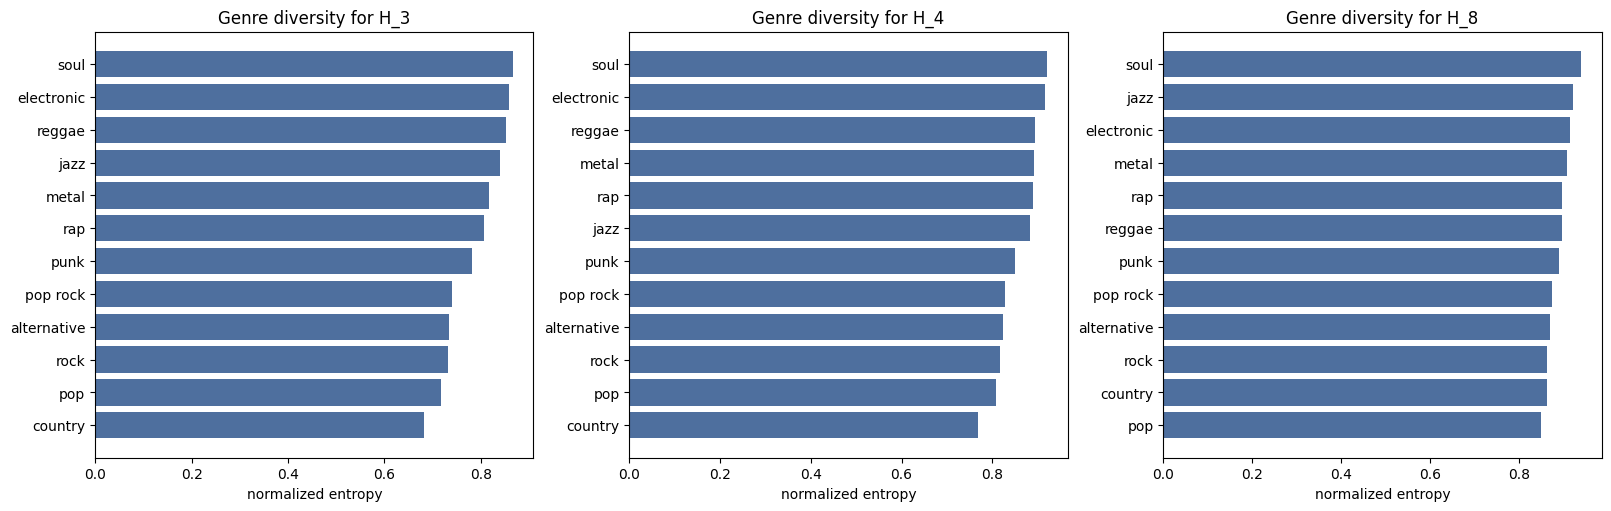

In [11]:
plot_df = genre_diversity_ranked[genre_diversity_ranked["n"].isin([3, 4, 8])].copy()
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
for ax, n in zip(axes, [3, 4, 8]):
    sub = plot_df[plot_df["n"] == n].sort_values("normalized_entropy")
    ax.barh(sub["main_genre"], sub["normalized_entropy"], color="#4e6f9e")
    ax.set_title(f"Genre diversity for H_{n}")
    ax.set_xlabel("normalized entropy")
plt.show()

## 6. Which Genres Have Signature Harmonic Language?

Diversity says how broad a genre is. Enrichment says what makes it distinctive.

In [12]:
genre_signature = genre_families.sort_values(["main_genre", "max_genre_lift"], ascending=[True, False])
display(genre_signature)
save_table(genre_signature, "genre_signature_families.csv")

for genre, sub in genre_signature.groupby("main_genre"):
    print(f"\n=== {genre} ===")
    display(sub.head(5)[["family_label", "family_kind", "n_values", "max_genre_lift", "representative_example_ngram", "frequency"]])

,main_genre,family_key,family_label,family_kind,n_values,max_genre_lift,n_rows,n,harmonic_id,representative_example_ngram,count,total_windows,frequency,other_genre_frequency,genre_lift
0,country,D7 G C,D7 G C,phrase,"3,4",6.718214,2,4,H4_a949538734bee773,D7 G C G,19382,3640372,0.005324,0.000792,6.718214
1,country,F C G7,F C G7,phrase,3,6.460602,1,3,H3_399df86a5aae7301,F C G7,20483,3693669,0.005545,0.000858,6.460602
2,country,C G7,C G7 loop,loop,3,5.093976,1,3,H3_3569c7a41696606d,C G7 C,34861,3693669,0.009438,0.001853,5.093976
3,country,G C G,G C G,phrase,"4,5,6,7",4.448107,6,7,H7_51295236d821371e,G C G D G D G,6525,3480588,0.001875,0.000421,4.448107
4,country,C G C,C G C,phrase,"6,7,8",4.424464,3,8,H8_6c733ce421b80711,C G C G D G C G,6524,3427416,0.001903,0.000430,4.424464
5,country,C D7 G,C D7 G,phrase,3,4.198188,1,3,H3_ea27575f6512821d,C D7 G,15617,3693669,0.004228,0.001007,4.198188
6,country,C G D,C G D,phrase,"4,5,6,7",4.191997,4,7,H7_6b19c9ff236fccec,C G D G C G C,7389,3480588,0.002123,0.000506,4.191997
7,country,G7 C,G7 C loop,loop,"3,4",4.103623,2,4,H4_cdf1acc292439936,G7 C G7 C,12200,3640372,0.003351,0.000817,4.103623
8,country,G D G,G D G,phrase,"4,5,6",4.059034,3,6,H6_60989f4eb4d1071f,G D G C G C,10217,3533818,0.002891,0.000712,4.059034
9,country,D G C,D G C,phrase,"4,5,6",4.011531,3,6,H6_7dc01e55295bbfbc,D G C G D G,34291,3533818,0.009704,0.002419,4.011531



=== country ===


,family_label,family_kind,n_values,max_genre_lift,representative_example_ngram,frequency
0,D7 G C,phrase,"3,4",6.718214,D7 G C G,0.005324
1,F C G7,phrase,3,6.460602,F C G7,0.005545
2,C G7 loop,loop,3,5.093976,C G7 C,0.009438
3,G C G,phrase,"4,5,6,7",4.448107,G C G D G D G,0.001875
4,C G C,phrase,"6,7,8",4.424464,C G C G D G C G,0.001903



=== electronic ===


,family_label,family_kind,n_values,max_genre_lift,representative_example_ngram,frequency
12,F Amin C,phrase,4,2.80317,F Amin C G,0.00383


...

,family_label,family_kind,n_values,max_genre_lift,representative_example_ngram,frequency
14,C G A,phrase,3,2.56338,C G A,0.006822



=== rap ===


,family_label,family_kind,n_values,max_genre_lift,representative_example_ngram,frequency
15,Emin Amin loop,loop,"3,4,5,6,7,8",8.010569,Emin Amin Emin Amin Emin Amin Emin Amin,0.007559
16,Amin Emin loop,loop,"3,4,5,6,7,8",7.812656,Amin Emin Amin Emin Amin Emin Amin Emin,0.007556
17,C Emin loop,loop,"5,6,7,8",5.454931,C Emin C Emin C Emin C Emin,0.004715
18,Emin C loop,loop,"5,7,8",5.333761,Emin C Emin C Emin C Emin C,0.004804



=== reggae ===


,family_label,family_kind,n_values,max_genre_lift,representative_example_ngram,frequency
19,Emin Amin loop,loop,"3,4,5,6,7,8",12.535692,Emin Amin Emin Amin Emin Amin Emin Amin,0.012901
20,Amin Emin loop,loop,"3,4,5,6,7,8",12.291270,Amin Emin Amin Emin Amin Emin Amin Emin,0.012928
21,G Amin loop,loop,"4,5,6,7,8",9.662534,G Amin G Amin G Amin G Amin,0.014688
22,Amin G loop,loop,"3,4,5,6,7,8",9.459528,Amin G Amin G Amin G Amin G,0.014767
23,C D C,phrase,8,4.911471,C D C G C D C G,0.002429


### Genre Reading

The genre sections are where “differently complex” should become concrete. Broad genres with high entropy are harmonic generalists; genres with high lift but lower entropy are more idiomatic. Both can be musically rich, but they organize harmonic vocabulary differently.

## 7. Harmonic Stop-Grams Versus Signature Terms

Stop-grams are high-frequency, high-document-frequency harmonic classes. They are musically real, but low-information for document identity. Signature terms are high-lift or high-TF-IDF terms within a document type.

In [13]:
stopgram_report = stopgrams.sort_values(["document_type", "n", "total_count"], ascending=[True, True, False])
display(stopgram_report.groupby(["document_type", "n"], as_index=False).head(10))
save_table(stopgram_report, "harmonic_stopgram_report.csv")

signature_report = enrichment_top.sort_values(["document_type", "document_value", "n", "lift"], ascending=[True, True, True, False])
display(signature_report.groupby(["document_type", "document_value", "n"], as_index=False).head(3))
save_table(signature_report, "harmonic_signature_enrichment_report.csv")

,document_type,n,harmonic_id,representative_example_ngram,total_count,document_frequency,max_document_count,max_document_tf,mean_document_tf_observed,normalized_entropy,n_documents,corpus_windows,document_frequency_rate,idf,background_frequency
0,decade_1950_plus,3,H3_ede3c4f53675bbb0,G C G,1349197,7,550307,0.070264,0.050943,0.836172,7,31129039,1.0,1.0,0.043342
1,decade_1950_plus,3,H3_35d6bfda85b78e3b,C G C,1182391,7,485709,0.062459,0.044686,0.835333,7,31129039,1.0,1.0,0.037984
2,decade_1950_plus,3,H3_4e99eecf61b0edec,C G D,1129297,7,539155,0.038340,0.032995,0.753586,7,31129039,1.0,1.0,0.036278
3,decade_1950_plus,3,H3_5f9ccd30c6b35272,C D G,754983,7,308486,0.030663,0.026467,0.821173,7,31129039,1.0,1.0,0.024253
4,decade_1950_plus,3,H3_614d8a0823c338e1,D G C,719108,7,300106,0.033234,0.026132,0.826291,7,31129039,1.0,1.0,0.023101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38088,main_genre,8,H8_3df2bb6a1623475c,G Amin F C G Amin F C,133811,12,50191,0.016357,0.006092,0.795885,12,24871783,1.0,1.0,0.005380
38089,main_genre,8,H8_8e587352081d119c,C G D C G D C G,106342,12,22693,0.005638,0.003803,0.803470,12,24871783,1.0,1.0,0.004276
38090,main_genre,8,H8_ff5a07db19706575,G D C G D C G D,105299,12,22446,0.005749,0.003789,0.805189,12,24871783,1.0,1.0,0.004234
38091,main_genre,8,H8_641a2adee2eee806,D C G D C G D C,101835,12,21720,0.005494,0.003645,0.803982,12,24871783,1.0,1.0,0.004094


,document_type,document_value,document_id,n,harmonic_id,example_ngram,global_count,global_frequency,count,total_windows,tf,song_count,document_frequency,document_frequency_rate,idf,background_frequency,tfidf_frequency,tfidf_log_count,n_documents,corpus_windows,total_count,vocab_size,rest_count,rest_windows,smoothed_doc_frequency,smoothed_rest_frequency,log2_lift,lift
0,decade_1950_plus,1960,decade_1950_plus:1960,3,H3_26faeefee79c95c8,A7 E7 B7,6147,0.000121,973,586092,0.001660,9488,7,1.000000,1.000000,0.000131,0.001660,6.881411,7,31129039,4083,2239,3110,30542947,0.001658,0.000102,4.024974,16.279387
1,decade_1950_plus,1960,decade_1950_plus:1960,3,H3_c71c0406d475a06d,E7 B7 A7,3918,0.000077,558,586092,0.000952,9488,7,1.000000,1.000000,0.000081,0.000952,6.326149,7,31129039,2531,2239,1973,30542947,0.000951,0.000065,3.879741,14.720357
2,decade_1950_plus,1960,decade_1950_plus:1960,3,H3_cdc67232bfce2ee6,B7 A7 E7,4127,0.000082,572,586092,0.000976,9488,7,1.000000,1.000000,0.000085,0.000976,6.350886,7,31129039,2639,2239,2067,30542947,0.000975,0.000068,3.848328,14.403309
175,decade_1950_plus,1960,decade_1950_plus:1960,4,H4_654a2d19d7d253f6,B7 A7 E7 B7,1478,0.000030,240,576612,0.000416,9488,7,1.000000,1.000000,0.000030,0.000416,5.484797,7,30709061,918,3428,678,30132449,0.000416,0.000023,4.207061,18.469351
176,decade_1950_plus,1960,decade_1950_plus:1960,4,H4_5bf092ee602ba305,D7 A7 E7 A7,2225,0.000045,398,576612,0.000690,9488,7,1.000000,1.000000,0.000050,0.000690,5.988961,7,30709061,1526,3428,1128,30132449,0.000689,0.000037,4.201618,18.399803
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2526,main_genre,soul,main_genre:soul,7,H7_adfb55bf01498bf8,D7 Amin7 D7 Amin7 D7 Amin7 D7,3094,0.000065,381,524252,0.000727,7350,10,0.833333,1.167054,0.000075,0.000848,6.938627,12,25222667,1904,3693,1523,24698415,0.000725,0.000062,3.555415,11.756731
2527,main_genre,soul,main_genre:soul,7,H7_5ffa54c2d1c2245b,Amin7 Dmin7 G7 Cmaj7 Amin7 Dmin7 G7,1227,0.000026,130,524252,0.000248,7350,9,0.750000,1.262364,0.000026,0.000313,6.154275,12,25222667,659,3693,529,24698415,0.000248,0.000021,3.532469,11.571217
2825,main_genre,soul,main_genre:soul,8,H8_bfdb7c923d892ec2,Bmin7 Cmaj7 Bmin7 Cmaj7 Bmin7 Cmaj7 Bmin7 Cmaj7,1018,0.000022,164,516920,0.000317,7350,10,0.833333,1.167054,0.000022,0.000370,5.958915,12,24871783,544,3262,380,24354863,0.000317,0.000016,4.343868,20.306475
2826,main_genre,soul,main_genre:soul,8,H8_781ba06276e8b62f,D7 Amin7 D7 Amin7 D7 Amin7 D7 Amin7,2341,0.000050,342,516920,0.000662,7350,9,0.750000,1.262364,0.000060,0.000835,7.369342,12,24871783,1499,3262,1157,24354863,0.000660,0.000048,3.796840,13.898338


PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/ultimate_eda/harmonic_signature_enrichment_report.csv')

## 8. When Did The Historical Regime Change?

A simple first-pass breakpoint proxy is the decade-to-decade distance between full frequency vectors. Larger distances indicate sharper vocabulary shifts. This uses the support-thresholded `H_n` document-term table.

,n,from_decade,to_decade,l1_distance,l2_distance,cosine_similarity
0,3,1950,1960,0.444358,0.035587,0.959950
5,3,2000,2010,0.218566,0.022427,0.977222
1,3,1960,1970,0.259094,0.022031,0.987313
7,4,1950,1960,0.396393,0.025855,0.937203
12,4,2000,2010,0.228857,0.015438,0.962465
8,4,1960,1970,0.264976,0.014920,0.982085
14,5,1950,1960,0.292046,0.020743,0.912499
19,5,2000,2010,0.212282,0.012910,0.949768
15,5,1960,1970,0.217788,0.011171,0.977690
21,6,1950,1960,0.222576,0.017211,0.883349


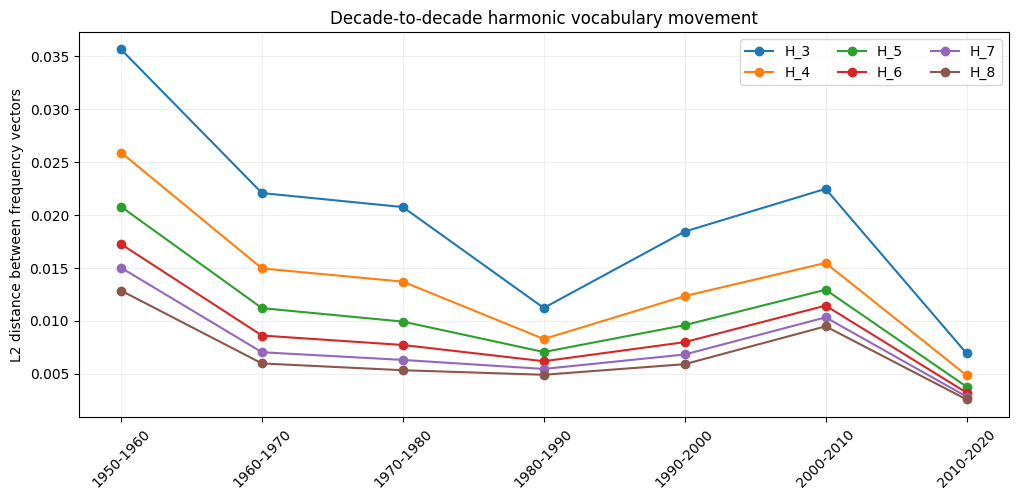

In [14]:
distance_rows = []
for n, sub in decade_terms.groupby("n"):
    pivot = sub.pivot_table(index="decade", columns="harmonic_id", values="frequency", fill_value=0.0).sort_index()
    decades = list(pivot.index)
    for left, right in zip(decades, decades[1:]):
        diff = pivot.loc[right] - pivot.loc[left]
        distance_rows.append(
            {
                "n": n,
                "from_decade": int(left),
                "to_decade": int(right),
                "l1_distance": float(diff.abs().sum()),
                "l2_distance": float(math.sqrt((diff * diff).sum())),
                "cosine_similarity": float((pivot.loc[left] @ pivot.loc[right]) / max(math.sqrt((pivot.loc[left] ** 2).sum()) * math.sqrt((pivot.loc[right] ** 2).sum()), 1e-12)),
            }
        )

decade_vector_distances = pd.DataFrame(distance_rows)
display(decade_vector_distances.sort_values(["n", "l2_distance"], ascending=[True, False]).groupby("n").head(3))
save_table(decade_vector_distances, "decade_to_decade_frequency_vector_distances.csv")

fig, ax = plt.subplots(figsize=(12, 5))
for n, sub in decade_vector_distances.groupby("n"):
    labels = [f"{a}-{b}" for a, b in zip(sub["from_decade"], sub["to_decade"])]
    ax.plot(labels, sub["l2_distance"], marker="o", label=f"H_{n}")
ax.set_title("Decade-to-decade harmonic vocabulary movement")
ax.set_ylabel("L2 distance between frequency vectors")
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.2)
ax.legend(ncol=3)
plt.show()

## 9. Artist-Level Generalists And Specialists

The current database does not store a full artist-by-harmonic-class table. This section builds a bounded artist profile by streaming the raw chord file for the top supported artists. It is intentionally parameterized at the top of the notebook.

Interpretation caveat: `artist_id` is anonymized, so this ranks catalog behavior without artist names.

This is a catalog-level diagnostic, not an artist-quality score. Because `artist_id` is anonymized and catalog sizes differ, use these rankings to find cases for follow-up inspection rather than as final claims.

In [15]:
def build_artist_harmonic_terms() -> pd.DataFrame:
    con = duckdb.connect(str(DB_PATH), read_only=True)
    try:
        artist_base = con.execute(
            """
            SELECT artist_id, COUNT(*) AS song_count
            FROM song_metadata
            WHERE artist_id IS NOT NULL
            GROUP BY artist_id
            HAVING COUNT(*) >= ?
            ORDER BY song_count DESC, artist_id
            LIMIT ?
            """,
            [MIN_ARTIST_SONGS, MAX_ARTISTS],
        ).fetchdf()
    finally:
        con.close()

    artists = set(artist_base["artist_id"])
    term_counts = Counter()
    windows = Counter()
    examples = {}
    parse_errors = Counter()

    for chunk in pd.read_csv(RAW_PATH, usecols=["id", "chords", "artist_id"], chunksize=CHUNKSIZE):
        chunk = chunk[chunk["artist_id"].isin(artists)]
        for row in chunk.itertuples(index=False):
            tokens = nf.chord_tokens(row.chords)
            for n in ARTIST_NS:
                ngrams = nf.chord_ngrams(tokens, n)
                windows[(row.artist_id, n)] += len(ngrams)
                for ngram in ngrams:
                    try:
                        key = nf.first_root_normalized_key(ngram)
                        hid = nf.harmonic_id(key)
                    except Exception as exc:
                        parse_errors[(n, type(exc).__name__)] += 1
                        continue
                    term_counts[(row.artist_id, n, hid)] += 1
                    examples.setdefault((n, hid), nf.ngram_label(ngram))

    rows = []
    song_counts = dict(zip(artist_base["artist_id"], artist_base["song_count"]))
    for (artist_id, n, harmonic_id), count in term_counts.items():
        total_windows = windows[(artist_id, n)]
        rows.append(
            {
                "artist_id": artist_id,
                "n": n,
                "harmonic_id": harmonic_id,
                "example_ngram": examples.get((n, harmonic_id)),
                "count": count,
                "total_windows": total_windows,
                "frequency": count / total_windows if total_windows else 0.0,
                "song_count": song_counts.get(artist_id),
            }
        )
    artist_terms = pd.DataFrame(rows)
    if parse_errors:
        display(pd.DataFrame([{"n": n, "error_type": err, "count": count} for (n, err), count in parse_errors.items()]))
    return artist_terms

if RUN_ARTIST_PROFILE:
    artist_terms = build_artist_harmonic_terms()
    artist_diversity = diversity_summary(artist_terms, ["artist_id", "n"]).sort_values(["n", "normalized_entropy"], ascending=[True, False])
    artist_diversity.to_csv(OUT_DIR / "artist_harmonic_diversity.csv", index=False)
    artist_terms.to_csv(OUT_DIR / "artist_harmonic_terms.csv", index=False)

    display(artist_diversity.sort_values(["n", "normalized_entropy"], ascending=[True, False]).groupby("n").head(10))
    display(artist_diversity.sort_values(["n", "normalized_entropy"], ascending=[True, True]).groupby("n").head(10))
else:
    artist_terms = pd.DataFrame()
    artist_diversity = pd.DataFrame()
    print("Set RUN_ARTIST_PROFILE = True to build artist-level harmonic diversity from the raw chord file.")

,artist_id,n,vocabulary_size,total_count,total_windows,song_count,entropy,normalized_entropy,effective_vocabulary,top1_share,top5_share,top20_share,gini
642,artist_6993,3,5113,15022,15022,180,7.824381,0.916253,2500.838453,0.015977,0.052590,0.113900,0.524572
468,artist_39857,3,1288,7775,7775,115,6.421507,0.896753,614.929041,0.013505,0.056720,0.165145,0.612562
357,artist_28140,3,938,5122,5122,113,6.117095,0.893822,453.545165,0.019133,0.086294,0.230964,0.585401
366,artist_2972,3,2727,14549,14549,119,7.014407,0.886670,1112.546773,0.018833,0.063166,0.154169,0.626002
459,artist_3822,3,1372,9550,9550,122,6.268680,0.867754,527.780024,0.024607,0.092042,0.237382,0.655953
525,artist_481,3,917,6388,6388,116,5.905881,0.865824,367.190534,0.018316,0.074984,0.235441,0.665356
375,artist_29809,3,1046,10972,10972,119,5.992656,0.861914,400.476940,0.021600,0.090412,0.234324,0.683622
312,artist_2494,3,2333,12431,12431,148,6.674355,0.860662,791.836705,0.022203,0.090821,0.210361,0.657820
219,artist_1954,3,3224,18419,18419,166,6.935464,0.858522,1028.096507,0.023508,0.095282,0.183723,0.677220
690,artist_81,3,768,9326,9326,114,5.649842,0.850394,284.246460,0.021553,0.087926,0.257560,0.708415


,artist_id,n,vocabulary_size,total_count,total_windows,song_count,entropy,normalized_entropy,effective_vocabulary,top1_share,top5_share,top20_share,gini
384,artist_304,3,807,39181,39181,633,3.905395,0.583476,49.669704,0.153084,0.467778,0.744927,0.908560
75,artist_1196,3,353,9748,9748,253,3.571232,0.608753,35.560366,0.161469,0.501641,0.800985,0.883532
261,artist_21628,3,154,6712,6712,177,3.083448,0.612165,21.833566,0.173421,0.564511,0.898987,0.876757
150,artist_15114,3,288,9350,9350,164,3.476629,0.613924,32.350482,0.166096,0.581283,0.782674,0.854916
354,artist_2782,3,535,14557,14557,364,3.920205,0.624011,50.410800,0.128667,0.463007,0.732637,0.875436
264,artist_21776,3,619,16543,16543,241,4.063116,0.632086,58.155261,0.121502,0.440730,0.700598,0.873686
537,artist_5057,3,1126,24042,24042,301,4.527863,0.644405,92.560543,0.111846,0.376799,0.627818,0.872555
456,artist_381,3,303,8067,8067,147,3.744039,0.655270,42.268351,0.153589,0.474278,0.739804,0.846190
282,artist_223,3,769,9557,9557,238,4.368067,0.657337,78.890976,0.129015,0.398556,0.655331,0.842620
165,artist_15998,3,487,10084,10084,188,4.074667,0.658451,58.830903,0.143395,0.459044,0.668584,0.839016


## 10. Report-Ready Takeaways

Run the cells above, then use this section as the compact digest for writing.

In [16]:
takeaways = []

for n, sub in largest_rises.groupby("n"):
    row = sub.sort_values("frequency_delta", ascending=False).iloc[0]
    takeaways.append({"question": "largest_rise", "n": n, "answer": row["representative_example_ngram"], "detail": f"{row['first_frequency']:.3%} -> {row['last_frequency']:.3%}"})
for n, sub in largest_declines.groupby("n"):
    row = sub.sort_values("frequency_delta", ascending=True).iloc[0]
    takeaways.append({"question": "largest_decline", "n": n, "answer": row["representative_example_ngram"], "detail": f"{row['first_frequency']:.3%} -> {row['last_frequency']:.3%}"})
for n, sub in decade_diversity_slopes.groupby("n"):
    row = sub.iloc[0]
    takeaways.append({"question": "diversity_slope", "n": n, "answer": "normalized_entropy", "detail": f"slope={row['normalized_entropy_slope']:.6f}"})

report_takeaways = pd.DataFrame(takeaways)
display(report_takeaways)
save_table(report_takeaways, "report_takeaways.csv")

{
    "outputs_written": sorted(p.name for p in OUT_DIR.glob("*.csv")),
    "artist_profile_ran": RUN_ARTIST_PROFILE,
}

,question,n,answer,detail
0,largest_rise,3,G Amin F,0.199% -> 2.063%
1,largest_rise,4,G Amin F G,0.091% -> 0.563%
2,largest_rise,5,Amin G F Amin G,0.073% -> 0.376%
3,largest_rise,6,F C G Amin F C,0.066% -> 1.047%
4,largest_rise,7,F C G Amin F C G,0.054% -> 0.964%
5,largest_decline,3,G C G,7.796% -> 3.605%
6,largest_decline,4,G C G C,3.642% -> 1.642%
7,largest_decline,5,G C G C G,2.367% -> 1.170%
8,largest_decline,6,G C G C G C,1.601% -> 0.857%
9,largest_decline,7,G C G D G C G,0.813% -> 0.238%


{'outputs_written': ['artist_harmonic_diversity.csv',
  'artist_harmonic_terms.csv',
  'decade_harmonic_diversity.csv',
  'decade_harmonic_diversity_slopes.csv',
  'decade_to_decade_frequency_vector_distances.csv',
  'genre_harmonic_diversity.csv',
  'genre_signature_families.csv',
  'harmonic_signature_enrichment_report.csv',
  'harmonic_stopgram_report.csv',
  'interpreted_family_summary.csv',
  'largest_supported_decade_declines.csv',
  'largest_supported_decade_rises.csv',
  'report_takeaways.csv',
  'song_length_by_decade.csv'],
 'artist_profile_ran': True}